In [1]:
import sys
sys.path.append('..')
import torch
import matplotlib.pyplot as plt
import numpy as np
from src.dataset import (get_transforms, TumorDataset,
                          SeverityDataset,
                          get_tumor_dataloaders,
                          get_severity_dataloaders)
from config import *
print(" Imports done")

Using device: cpu
 Imports done


In [2]:
train_loader, val_loader, test_loader = get_tumor_dataloaders()

# Check one batch
images, labels = next(iter(train_loader))
print(f"Batch shape  : {images.shape}")
print(f"Labels shape : {labels.shape}")
print(f"Pixel min    : {images.min():.4f}")
print(f"Pixel max    : {images.max():.4f}")
print(f"Pixel mean   : {images.mean():.4f}")

Loaded 5600 images from e:\Collage_submission\NeuroVision-AI\notebooks\..\data\tumor_type\Training
Loaded 1600 images from e:\Collage_submission\NeuroVision-AI\notebooks\..\data\tumor_type\Testing

DataLoaders ready:
  Train : 5600 images
  Val   : 800 images
  Test  : 800 images
Batch shape  : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Pixel min    : -1.0121
Pixel max    : 4.5011
Pixel mean   : 0.0740


In [3]:
sev_train, sev_val, sev_test = get_severity_dataloaders()

images, labels = next(iter(sev_train))
print(f"Severity batch shape : {images.shape}")
print(f"Unique labels in batch: {labels.unique()}")

Severity dataset: 1268 images | 6 classes

Severity DataLoaders ready:
  Train : 887 images
  Val   : 190 images
  Test  : 191 images
Severity batch shape : torch.Size([32, 3, 224, 224])
Unique labels in batch: tensor([0, 1, 2, 3, 4, 5])


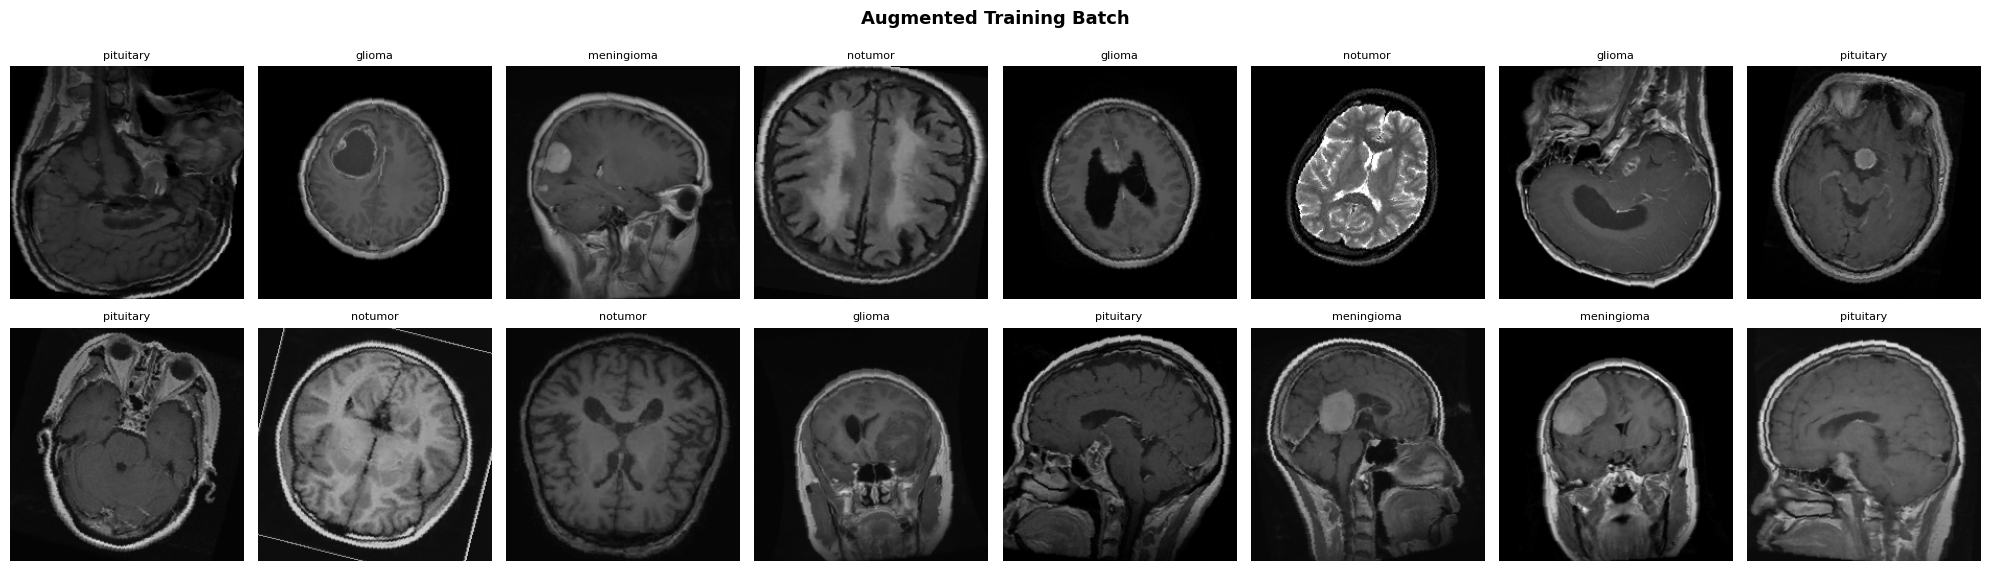

In [4]:
def show_batch(loader, class_names, title='Batch'):
    images, labels = next(iter(loader))
    # Denormalize
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    imgs = images * std + mean
    imgs = imgs.clamp(0, 1)

    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    axes = axes.flatten()
    for i in range(min(16, len(imgs))):
        img = imgs[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]],
                          fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{title.lower()}.png')
    plt.show()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
show_batch(train_loader, TUMOR_CLASSES,
           'Augmented Training Batch')

In [5]:
from src.dataset import SeverityDataset
from config import SEVERITY_FOLDERS, SEVERITY_DIR

ds = SeverityDataset(SEVERITY_DIR, SEVERITY_FOLDERS)
counts = ds.get_class_counts()

print("\nSeverity Class Distribution:")
for cls, cnt in zip(ds.class_names, counts):
    print(f"  {cls:15s}: {cnt} images")

print(f"\nTotal: {sum(counts)} images")

Severity dataset: 1268 images | 6 classes

Severity Class Distribution:
  glioma         : 371 images
  meningioma     : 519 images
  neurocitoma    : 144 images
  normal         : 89 images
  outros         : 45 images
  schwannoma     : 100 images

Total: 1268 images


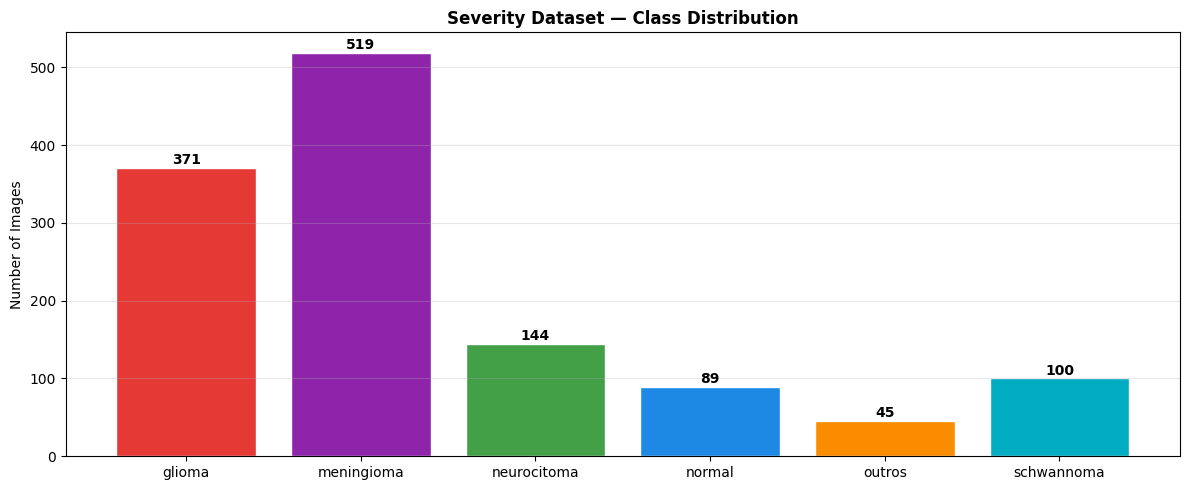


Imbalance ratio: 11.53x
  Dataset is imbalanced — will use weighted loss in training


In [6]:
import matplotlib.pyplot as plt

colors = ['#E53935', '#8E24AA', '#43A047',
          '#1E88E5', '#FB8C00', '#00ACC1']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(ds.class_names, counts,
              color=colors, edgecolor='white')
ax.set_title('Severity Dataset — Class Distribution',
             fontweight='bold')
ax.set_ylabel('Number of Images')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'severity_class_dist.png')
plt.show()

# Check if imbalanced
max_cnt = max(counts)
min_cnt = min(counts)
ratio   = max_cnt / min_cnt
print(f"\nImbalance ratio: {ratio:.2f}x")
if ratio > 2:
    print("  Dataset is imbalanced — "
          "will use weighted loss in training")
else:
    print(" Dataset is balanced enough")